# Week 5: EDA and Correlation Check

## Goals
- Examine the distribution of key variables
- Check simple correlations
- Visualize the relationship between foreign population ratio and station accessibility
- Compare Kawaguchi-shi and Edogawa-ku

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_raw = project_root / "data_raw"

tokyo_path = data_raw / "tokyo_features_v1.geojson"
tokyo = gpd.read_file(tokyo_path)

print(tokyo.shape)
print(tokyo.columns.tolist())
tokyo.head()

(227, 13)
['N03_007', 'N03_001', 'N03_004', 'N03_005', 'total_pop', 'foreign_pop', 'foreign_ratio', 'dist_to_station_m', 'nearest_station_name', 'nearest_line_name', 'nearest_operator', 'log_dist_to_station_m', 'geometry']


,N03_007,N03_001,N03_004,N03_005,total_pop,foreign_pop,foreign_ratio,dist_to_station_m,nearest_station_name,nearest_line_name,nearest_operator,log_dist_to_station_m,geometry
0,11101,埼玉県,さいたま市,西区,95251,1469,0.015422,1217.639796,指扇,川越線,東日本旅客鉄道,7.105491,"MULTIPOLYGON (((-25741.989 -7274.146, -25724.9..."
1,11102,埼玉県,さいたま市,北区,150366,2775,0.018455,376.317982,加茂宮,伊奈線,埼玉新都市交通,5.933088,"POLYGON ((-19464.582 -3877.533, -19423.753 -38..."
2,11103,埼玉県,さいたま市,大宮区,124703,3389,0.027177,18.735225,大宮,東北線,東日本旅客鉄道,2.982405,"POLYGON ((-17656.644 -8549.615, -17623.916 -85..."
3,11104,埼玉県,さいたま市,見沼区,165105,3594,0.021768,1005.052129,七里,野田線,東武鉄道,6.913789,"POLYGON ((-14986.573 -3932.152, -14966.946 -39..."
4,11105,埼玉県,さいたま市,中央区,103107,2061,0.019989,94.227971,与野本町,東北線,東日本旅客鉄道,4.556274,"POLYGON ((-19047.367 -10824.812, -19007.183 -1..."


In [3]:
tokyo["foreign_ratio"] = pd.to_numeric(tokyo["foreign_ratio"], errors="coerce")
tokyo["dist_to_station_m"] = pd.to_numeric(tokyo["dist_to_station_m"], errors="coerce")

if "log_dist_to_station_m" not in tokyo.columns:
    tokyo["log_dist_to_station_m"] = np.log1p(tokyo["dist_to_station_m"])

tokyo[["foreign_ratio", "dist_to_station_m", "log_dist_to_station_m"]].dtypes

foreign_ratio            float64
dist_to_station_m        float64
log_dist_to_station_m    float64
dtype: object

In [4]:
tokyo[["foreign_ratio", "dist_to_station_m", "log_dist_to_station_m"]].isna().sum()

foreign_ratio            0
dist_to_station_m        0
log_dist_to_station_m    0
dtype: int64

In [5]:
tokyo[["foreign_ratio", "dist_to_station_m", "log_dist_to_station_m"]].describe()

,foreign_ratio,dist_to_station_m,log_dist_to_station_m
count,227.000000,227.000000,227.000000
mean,0.030570,1637.975651,6.935885
std,0.020461,1640.823796,1.064145
min,0.004448,3.260248,1.449327
25%,0.017700,575.631799,6.357198
50%,0.024931,1019.045177,6.927602
75%,0.034596,2205.548485,7.699182
max,0.125698,8418.151585,9.038264


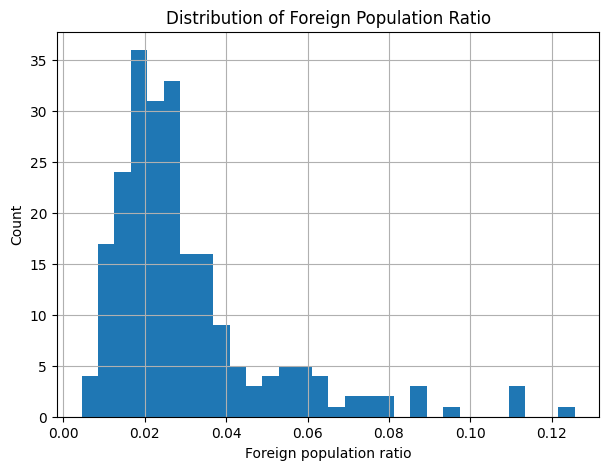

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
tokyo["foreign_ratio"].hist(bins=30, ax=ax)

ax.set_title("Distribution of Foreign Population Ratio")
ax.set_xlabel("Foreign population ratio")
ax.set_ylabel("Count")

plt.show()

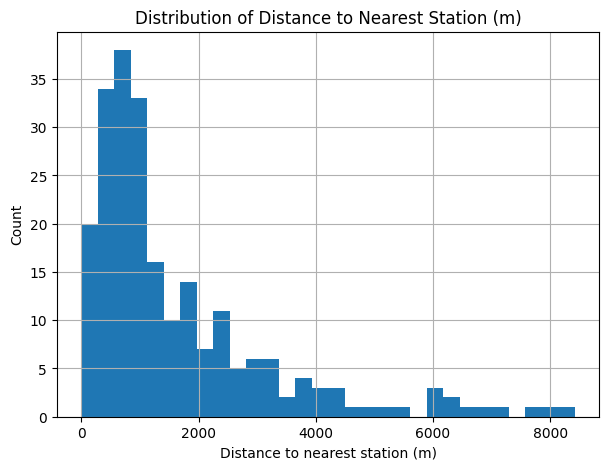

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
tokyo["dist_to_station_m"].hist(bins=30, ax=ax)

ax.set_title("Distribution of Distance to Nearest Station (m)")
ax.set_xlabel("Distance to nearest station (m)")
ax.set_ylabel("Count")

plt.show()

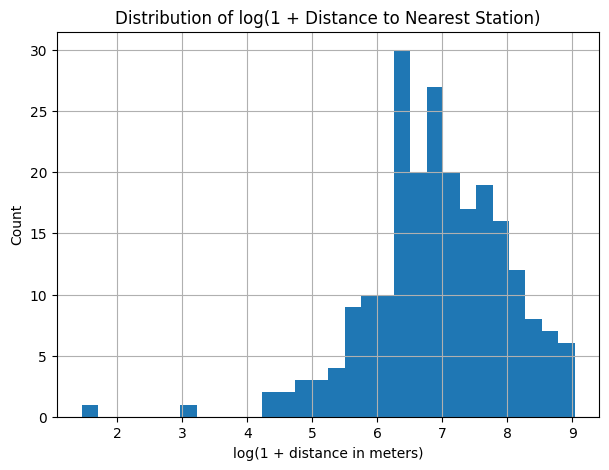

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
tokyo["log_dist_to_station_m"].hist(bins=30, ax=ax)

ax.set_title("Distribution of log(1 + Distance to Nearest Station)")
ax.set_xlabel("log(1 + distance in meters)")
ax.set_ylabel("Count")

plt.show()

In [9]:
corr_df = tokyo[["foreign_ratio", "dist_to_station_m", "log_dist_to_station_m"]].corr()
corr_df

,foreign_ratio,dist_to_station_m,log_dist_to_station_m
foreign_ratio,1.000000,-0.208195,-0.333295
dist_to_station_m,-0.208195,1.000000,0.817114
log_dist_to_station_m,-0.333295,0.817114,1.000000


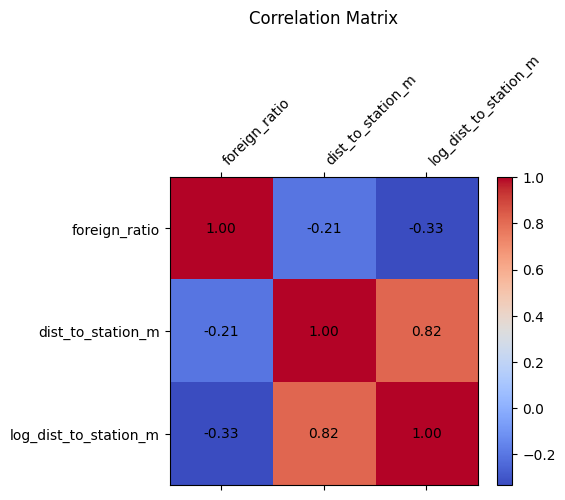

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))

cax = ax.matshow(corr_df, cmap="coolwarm")
fig.colorbar(cax)

ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha="left")
ax.set_yticklabels(corr_df.columns)

for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", va="center", ha="center")

ax.set_title("Correlation Matrix", pad=20)
plt.show()

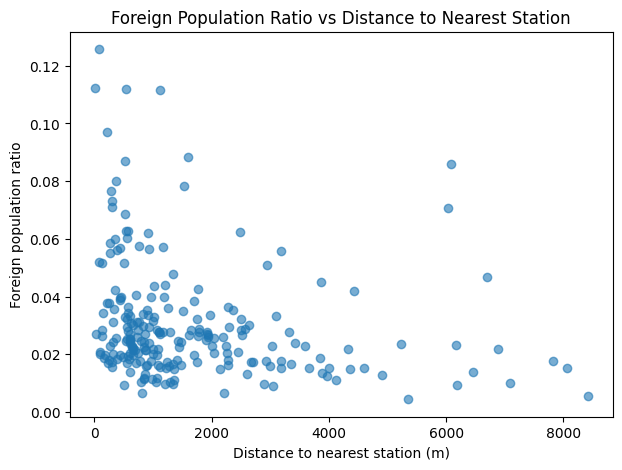

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

x = tokyo["dist_to_station_m"]
y = tokyo["foreign_ratio"]

ax.scatter(x, y, alpha=0.6)

ax.set_xlabel("Distance to nearest station (m)")
ax.set_ylabel("Foreign population ratio")
ax.set_title("Foreign Population Ratio vs Distance to Nearest Station")

plt.show()

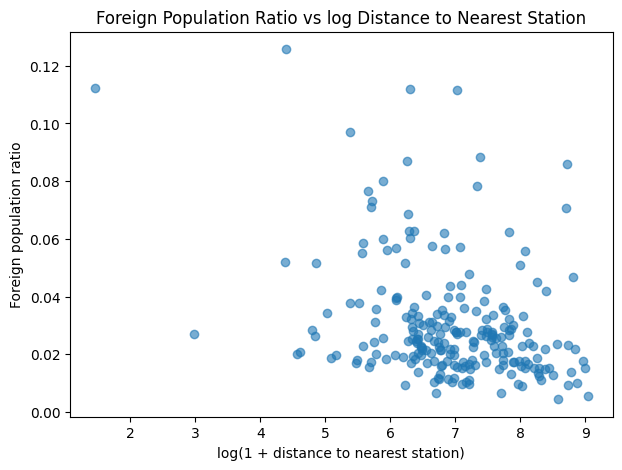

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

x = tokyo["log_dist_to_station_m"]
y = tokyo["foreign_ratio"]

ax.scatter(x, y, alpha=0.6)

ax.set_xlabel("log(1 + distance to nearest station)")
ax.set_ylabel("Foreign population ratio")
ax.set_title("Foreign Population Ratio vs log Distance to Nearest Station")

plt.show()

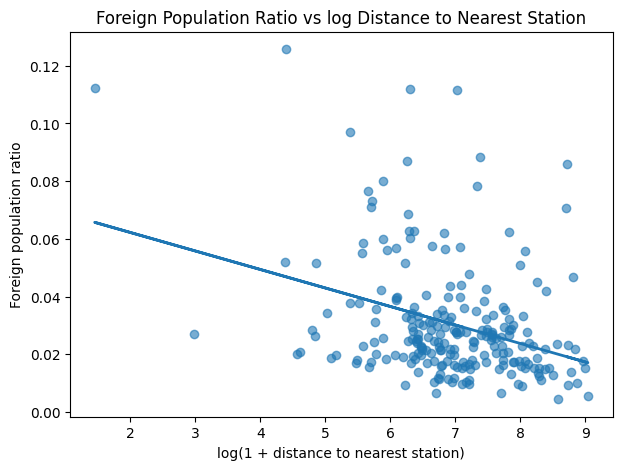

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

x = tokyo["log_dist_to_station_m"]
y = tokyo["foreign_ratio"]

ax.scatter(x, y, alpha=0.6)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(x, p(x), linewidth=2)

ax.set_xlabel("log(1 + distance to nearest station)")
ax.set_ylabel("Foreign population ratio")
ax.set_title("Foreign Population Ratio vs log Distance to Nearest Station")

plt.show()

In [14]:
case_compare = tokyo[
    tokyo["N03_004"].astype(str).str.contains("川口|江戸川", na=False) |
    tokyo["N03_005"].astype(str).str.contains("川口|江戸川", na=False)
].copy()

case_compare[[
    "N03_001", "N03_004", "N03_005", "N03_007",
    "foreign_ratio", "dist_to_station_m",
    "nearest_station_name", "nearest_line_name"
]]

,N03_001,N03_004,N03_005,N03_007,foreign_ratio,dist_to_station_m,nearest_station_name,nearest_line_name
12,埼玉県,川口市,,11203,0.071131,300.302318,鳩ヶ谷,埼玉高速鉄道線
138,東京都,江戸川区,,13123,0.062204,919.207429,一之江,10号線新宿線


In [15]:
tokyo[[
    "N03_001", "N03_004", "N03_005",
    "foreign_ratio", "dist_to_station_m"
]].sort_values("foreign_ratio", ascending=False).head(10)

,N03_001,N03_004,N03_005,foreign_ratio,dist_to_station_m
119,東京都,新宿区,,0.125698,79.704459
131,東京都,豊島区,,0.112230,3.260248
28,埼玉県,蕨市,,0.112048,545.913250
172,神奈川県,横浜市,中区,0.111693,1114.537814
133,東京都,荒川区,,0.096918,215.951611
222,神奈川県,箱根町,,0.088384,1600.792602
121,東京都,台東区,,0.087034,518.443566
225,神奈川県,愛川町,,0.085878,6078.656201
118,東京都,港区,,0.079901,358.857324
187,神奈川県,川崎市,川崎区,0.078258,1529.928943


In [16]:
tokyo[[
    "N03_001", "N03_004", "N03_005",
    "foreign_ratio", "dist_to_station_m"
]].sort_values("dist_to_station_m", ascending=False).head(10)

,N03_001,N03_004,N03_005,foreign_ratio,dist_to_station_m
167,東京都,檜原村,,0.005539,8418.151585
63,埼玉県,小鹿野町,,0.015316,8062.974766
112,千葉県,長柄町,,0.017733,7818.489165
113,千葉県,長南町,,0.010079,7091.276367
56,埼玉県,川島町,,0.021988,6883.666613
66,埼玉県,神川町,,0.046710,6698.419827
220,神奈川県,山北町,,0.013778,6450.022026
111,千葉県,睦沢町,,0.009525,6186.751439
226,神奈川県,清川村,,0.023155,6166.369065
225,神奈川県,愛川町,,0.085878,6078.656201


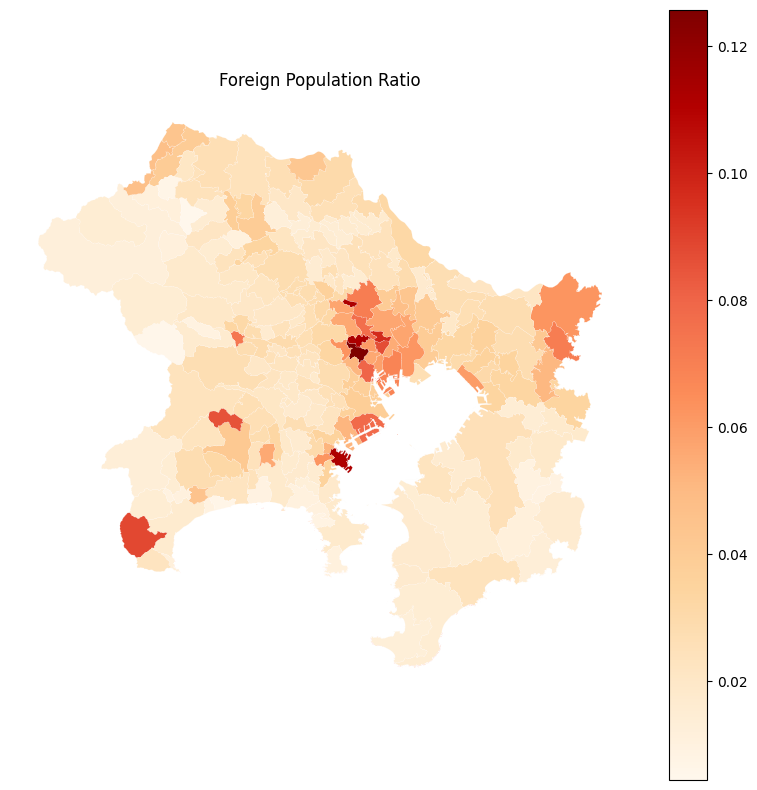

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

tokyo.plot(
    column="foreign_ratio",
    cmap="OrRd",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title("Foreign Population Ratio")
ax.set_axis_off()
plt.show()

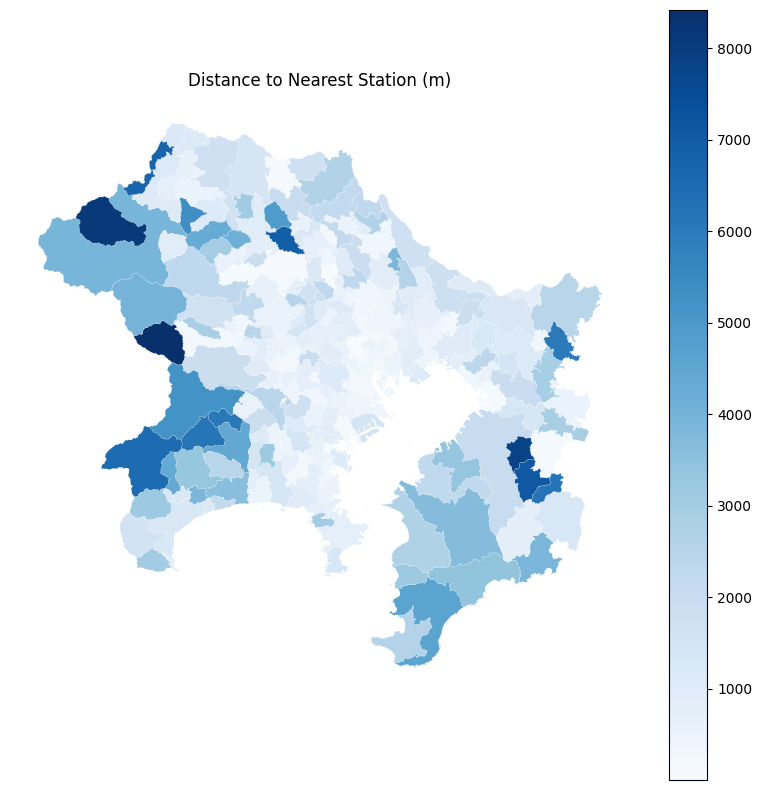

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))

tokyo.plot(
    column="dist_to_station_m",
    cmap="Blues",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title("Distance to Nearest Station (m)")
ax.set_axis_off()
plt.show()

## Preliminary findings

1. The foreign population ratio shows clear spatial variation across the Tokyo metropolitan mainland area.

2. Station accessibility appears to be related to foreign population concentration. The correlation between foreign population ratio and raw station distance is negative (-0.21), and the relationship becomes stronger when the log-transformed station distance is used (-0.33).

3. This suggests that municipal units with better railway accessibility tend to have higher foreign population shares, although the relationship is not strong enough to imply a single-factor explanation.

4. Kawaguchi-shi and Edogawa-ku both show relatively high foreign population ratios under urban transit accessibility conditions, but they differ in their nearest-station contexts and local rail settings.

5. The current results support the inclusion of station accessibility as a key explanatory variable in the next-stage regression and MGWR analysis.